In [1]:
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
from files.pezw2 import pezw2

Σε αυτή την άσκηση θα χρησιμοποιήσετε αρκετά μια custom συνάρτηση που ονομάζεται pezw2, η οποία τυπώνει μερικά ενδιαφέροντα γραφήματα σχετικά με μια συνάρτηση μεταφοράς $$H(z) = \frac{P(z)}{Q(z)}$$

Δείτε παρακάτω τι κάνει και πως συντάσσεται.

In [2]:
help(pezw2)

Help on function pezw2 in module files.pezw2:

pezw2(B, A)
    pezw2(B,A)
    
    Η PEZW2(B,A) σχεδιάζει
    (a) το μέτρο του H(z),
    (b) τα μηδενικά και τους πόλους (με τον μοναδιαίο κύκλο ως αναφορά),
    (c) το φάσμα πλάτους και φάσης του συστήματος,
    (d) την κρουστική απόκριση h[n] (τα πρώτα 100 δείγματα), και
    (e) την καθυστέρηση ομάδας του συστήματος.
    
    Τα B και A είναι πολυώνυμα ως προς z^-1:
    B(z): διάνυσμα που περιέχει τους συντελεστές του αριθμητή σε φθίνουσα
    σειρά δυνάμεων του z^-1
    A(z): διάνυσμα που περιέχει τους συντελεστές του παρονομαστή σε φθίνουσα
    σειρά δυνάμεων του z^-1
    
    Παραδείγματα:
    για τη συνάρτηση μεταφοράς H(z) = 1/(1-0.4z^-1), καλέστε pezw2([1], [1, -0.4]);
    για τη συνάρτηση μεταφοράς H(z) = 1/(1 - 0.6exp(jπ/2)z^-1)(1 - 0.6exp(-jπ/2)z^-1), καλέστε
    pezw2([1], np.convolve([1, 0.6*np.exp(1j*np.pi/2)], [1, 0.6*np.exp(-1j*np.pi/2)])



"Ξε-σχολιάστε" τα δυο παραδείγματα και εξετάστε τα γραφήματα ώστε να καταλάβετε περισσότερα.

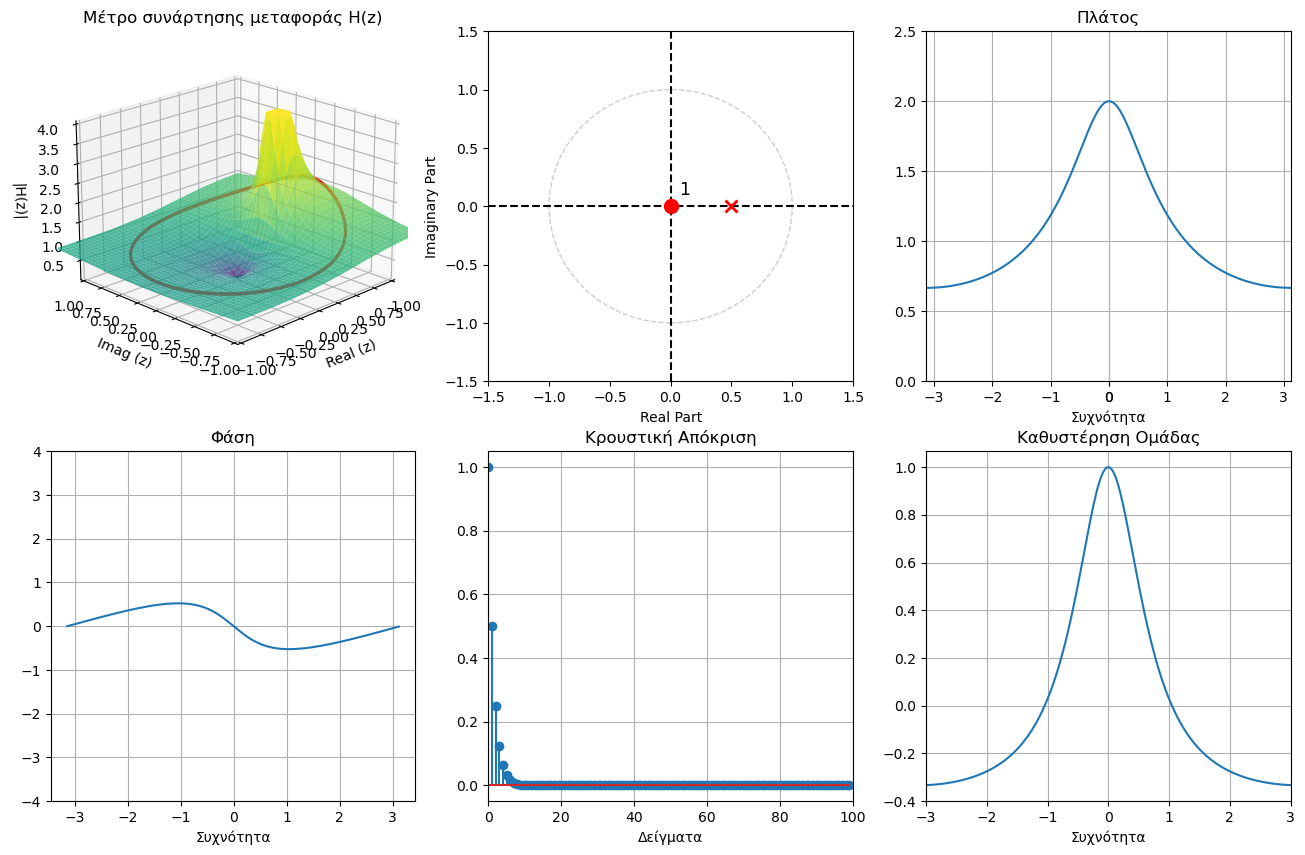

In [3]:
pezw2([1], [1, -0.5])

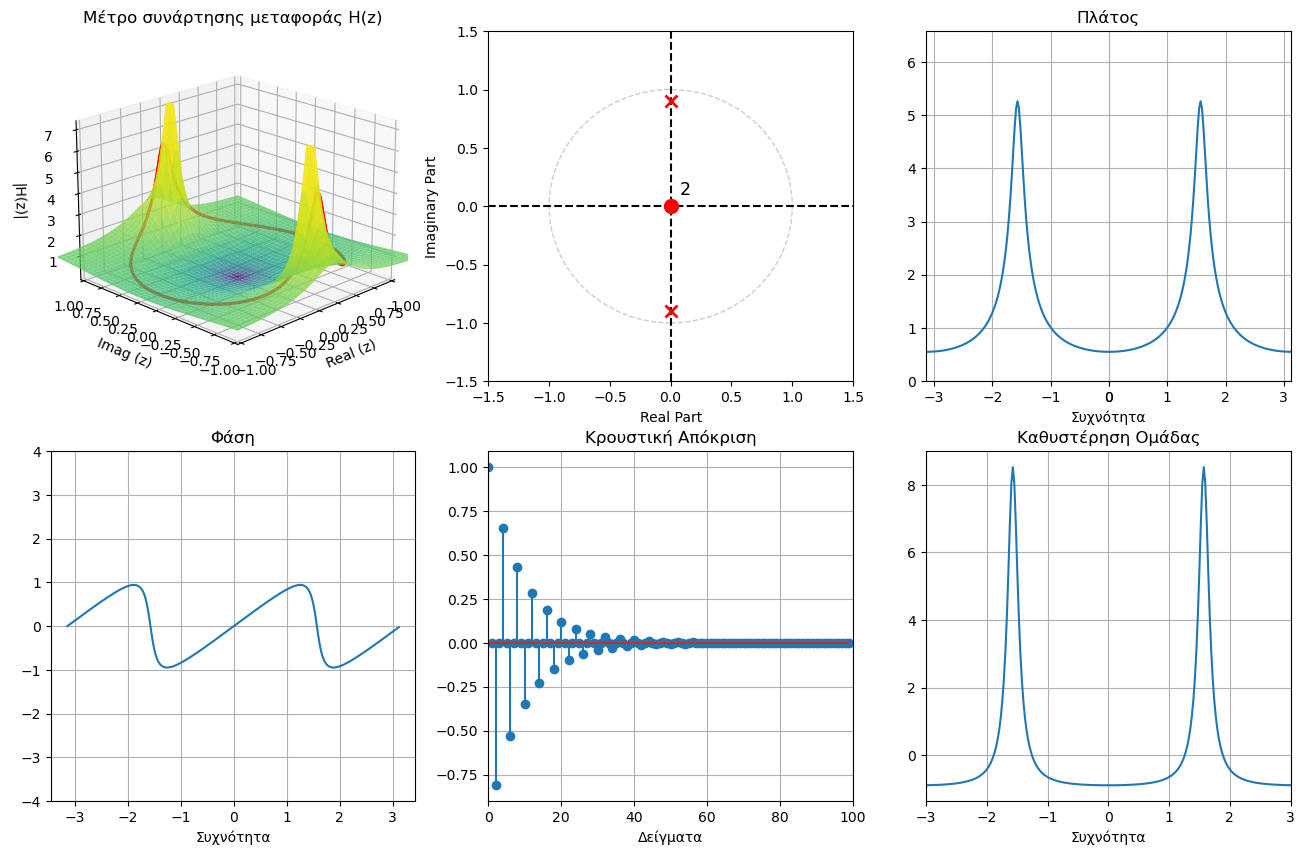

In [4]:
pezw2([1], np.convolve([1, -0.9*np.exp(1j*np.pi/2)], [1, -0.9*np.exp(-1j*np.pi/2)]))

---
---

## Άσκηση - Κατανόηση Καθυστέρηση Ομάδας και All-pass Συστημάτων
Έστω ένα all-pass σύστημα με έναν πόλο $a$ και ένα μηδενικό $1/a^*$, με $a=re^{j\theta}$ και $|r|<1$, δηλ. της μορφής

$$H(z) = \frac{z^{-1}-a^*}{1 - az^{-1}}$$

Προφανώς, ένα τέτοιο σύστημα ΔΕΝ είναι πραγματικό (δηλ. $h[n] \notin \mathbb{R}$) γιατί ο πόλος και το μηδενικό δεν έχουν το συζυγές τους "ταίρι".

Σύμφωνα με τις διαλέξεις, ένα τέτοιο σύστημα θα έχει group delay (καθυστέρηση ομάδας) της μορφής:

$$grd[H(e^{j\omega})] = \frac{1 - r^{2}}{|1 - re^{j\theta} e^{-j\omega}|^{2}} = \frac{1 - r^{2}}{1 + r^{2} - 2r \cos (\omega - \theta)}$$

Ακόμα, γνωρίζουμε ότι το group delay του συστήματος θα έχει μέγιστο στο $\omega = \theta$, όπου:

$$\max (grd[H(e^{j\omega})]) = \frac{1 - r^{2}}{1 + r^{2} - 2r\cos(0)} = \frac{1 - r^{2}}{1 + r^{2} -2r} = \frac{(1-r)(1+r)}{(1-r)^2} \Longrightarrow {\max (grd[H(e^{j\omega})]) = \frac{1+r}{1-r}}$$


Αν βάλουμε στο μιγαδικό επίπεδο και το συζυγές "ταίρι" κάθε μηδενικού/πόλου, τότε παρατηρούμε - με όμοια διαδικασία με παραπάνω - ότι υπάρχει κι ένα δεύτερο μέγιστο, στη θέση $\omega = -\theta$, και το μέγιστο αυτό έχει την ίδια τιμή: $$(1+r)/(1-r)$$

Τι σημαίνει η τιμή αυτή του group delay στη συγκεκριμένη συχνότητα για ένα "πακέτο" συχνοτήτων στενής ζώνης με κεντρική συχνότητα $\omega=\theta$ που εμφανίζεται στην είσοδο? Με άλλα λόγια, αν ένας πεπρασμένης διάρκειας παλμός της μορφής 

$$x[n] = w[n]\cos(\theta n)$$

με $w[n]$ μια περιβάλλουσα στενής ζώνης διάρκειας $M$ για την οποία ισχύει

$$w[n] = 0, \: n \leq 0, \: n \geq M$$

τότε τι περιμένετε να συμβεί στην έξοδο? **Απαντήστε παρακάτω**.

<u>**Απάντηση**</u>

Αυτή η τιμή του group delay πρακτικά σημαίνει ότι αν εμφανιστεί στην είσοδο του συστήματος ένα πακέτο συχνοτήτων στενής ζώνης στη συγκεκριμένη συχνότητα $\theta$, στην έξοδο θα προκύψει πακέτο που θα έχει υποστεί χρονική καθυστέρηση κατά $$\frac{1+r}{1-r}$$ δείγματα.


---

Δημιουργούμε ένα σήμα με τις παρακάτω εντολές:


In [5]:
x1 = [np.multiply(np.cos(np.dot((np.pi/4), np.array([i for i in range(0, 301)]))), np.hanning(301))]
x2 = [np.multiply(np.cos(np.dot((np.pi/2), np.array([i for i in range(0, 301)]))), np.hanning(301))]
x = np.hstack([np.zeros((1,300)), x1, x2, np.zeros((1,300))])[0]

Το παραπάνω σήμα έχει δυο ημίτονα στις συχνότητες $\omega_1 = 0.25\pi$ και $\omega_2 = 0.5\pi$, όπως είναι εμφανές, ενώ η διάρκειά τους είναι $301$ δείγματα. Με βάση τις απαντήσεις και τις παρατηρήσεις σας για το all-pass σύστημα νωρίτερα, και χρησιμοποιώντας τη συνάρτηση ``pezw2`` που σας δίνεται, εκτελέστε τα παρακάτω:

i. Ας τυπώσουμε το γράφημα (εντολή ``plt.plot``) του σήματος $x$.


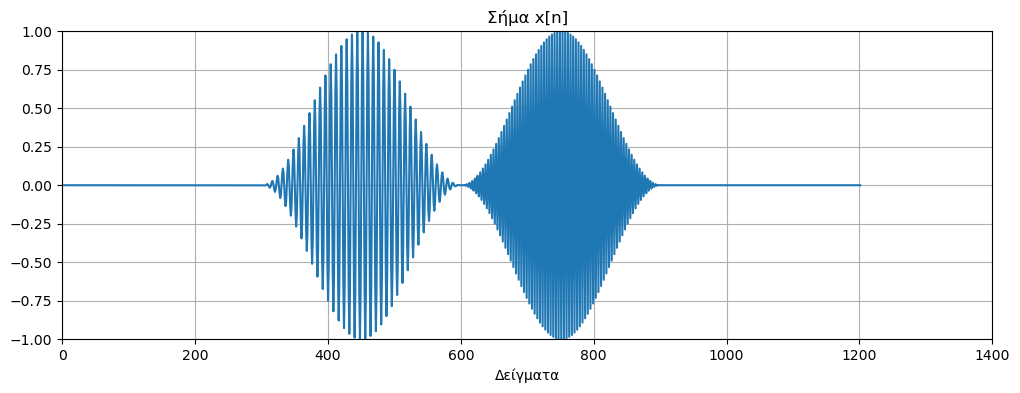

In [6]:
fig = plt.figure(figsize=(12,4))
plt.plot(x)
plt.grid(True)
plt.xlabel('Δείγματα')
plt.title("Σήμα x[n]")
plt.xlim(0, 1400)
plt.ylim(-1.00, 1.00)
plt.show()

ii. Δημιουργήστε ένα **πραγματικό** all-pass σύστημα το οποίο να μετατοπίζει μόνο το πρώτο ημίτονο κατά $50$ δείγματα.
Θυμηθείτε που βρίσκονται πόλοι και μηδενικά ενός τέτοιου συστήματος, βρείτε τους συντελεστές του συστήματος, για αριθμητή και παρονομαστή. Καλέστε τη συνάρτηση ``pezw2`` με κατάλληλα ορίσματα. Περάστε το σήμα σας μέσα από το σύστημα (εντολή ``sig.lfilter``). Τυπώστε (εντολή ``plt.plot``) το αποτέλεσμα της εξόδου.

<u>**Απάντηση**</u>

Για να μετακινηθεί το πρώτο ημίτονο κατά $50$ δείγματα, πρέπει (όπως συζητήσαμε στο θεωρητικό κομμάτι) να είναι:
$$\max \big(grd[H (e^{j\omega})]\big) = 50 \Rightarrow \frac{1+r}{1-r} = 50 \Rightarrow 1 + r = 50 - 50r \Rightarrow 51r = 49 \Rightarrow r = \frac{49}{51}$$
Το πρώτο ημίτονο έχει συχνότητα $0.25 \pi$, οπότε πρέπει το σύστημα να έχει $2$ πόλους στις συχνότητες $\pm \frac{\pi}{4}$ - γιατί από τους τύπους του Euler προκύπτει $$\cos(\frac{\pi n}{4}) = \frac{1}{2}e^{j\frac{\pi n}{4}}+ \frac{1}{2}e^{-j\frac{\pi n}{4}}$$ 

Έτσι, οι πόλοι θα είναι στα σημεία $\alpha_{1} = \frac{49}{51}e^{j\frac{\pi}{4}}, \alpha_{2} = \frac{49}{51}e^{-j\frac{\pi}{4}}$. Επειδή το σύστημα είναι all-pass, θα έχει και $2$ μηδενικά στις θέσεις $z_{1} = \frac{1}{\alpha_{1}^{*}}$, $z_{2} = \frac{1}{\alpha_{2}^{*}}$. Έτσι, για το τελικό σύστημα θα ισχύει:

$$H_{1}(z) = \frac{(z^{-1} - \alpha_{1}^{*})(z^{-1} - \alpha_{2}^{*})}{(1 - \alpha_{1}z^{-1})(1 - \alpha_{2}z^{-1})} \Longrightarrow H_{1}(z) = \frac{(-\frac{49}{51}e^{-j\frac{\pi}{4}} + z^{-1})(-\frac{49}{51}e^{j\frac{\pi}{4}} + z^{-1})}{(1 - \frac{49}{51}e^{-j\frac{\pi}{4}}z^{-1})(1 -\frac{49}{51}e^{j\frac{\pi}{4}}z^{-1})}$$


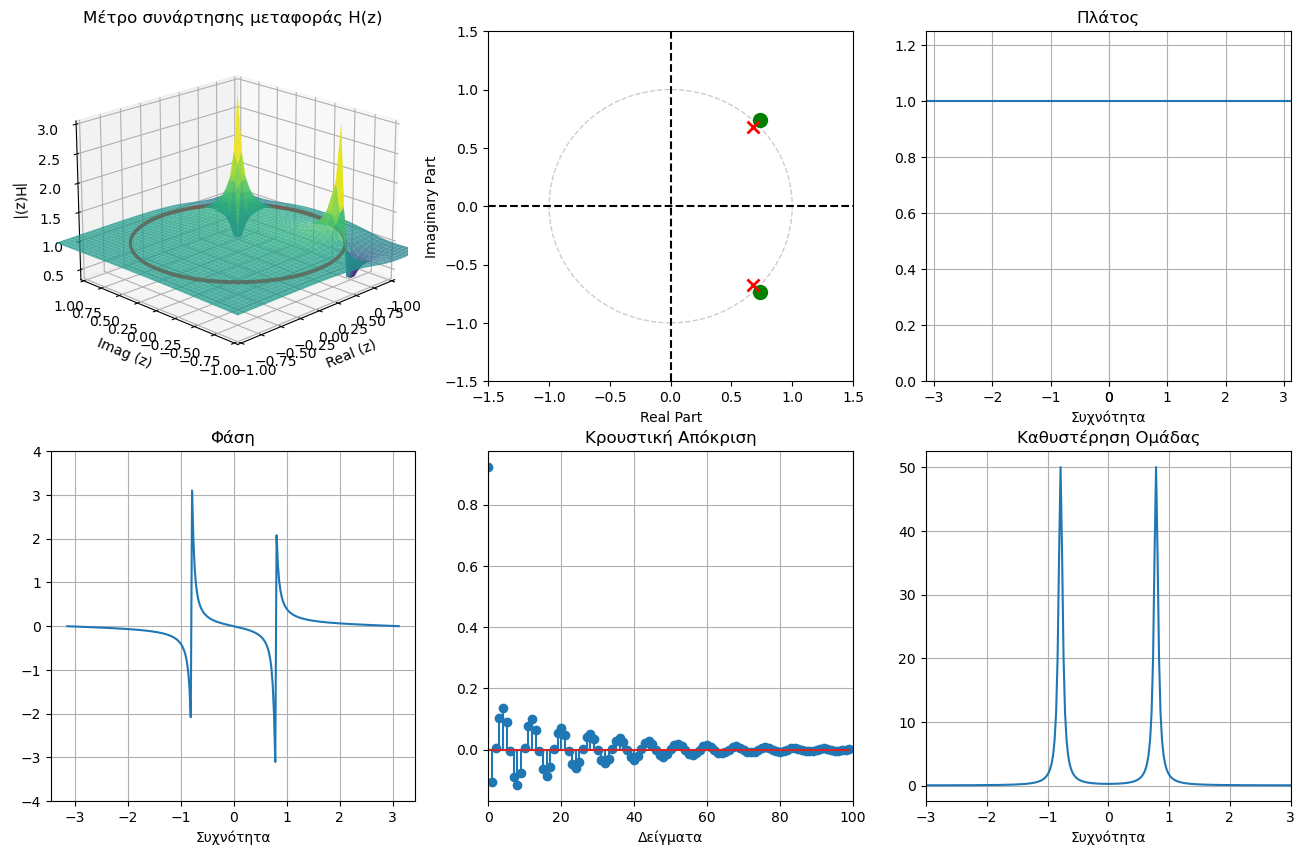

In [7]:
r = 49/51
w = np.pi/4

num1 = (sig.convolve([-r*np.exp(-1j*w), 1], [-r*np.exp(1j*w), 1]))
den1 = (sig.convolve([1, -r*np.exp(1j*w)], [1, -r*np.exp(-1j*w)]))

pezw2(num1, den1)

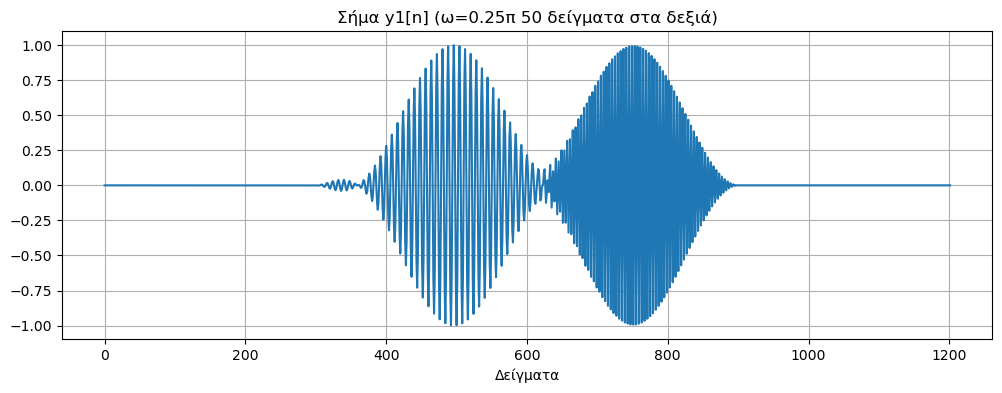

In [8]:
# Φιλτράρισμα και γράφημα εξόδου
y1 = sig.lfilter(num1, den1, x)

plt.figure(figsize=(12,4))
plt.plot(y1)
plt.grid(True)
plt.xlabel('Δείγματα')
plt.title('Σήμα y1[n] (ω=0.25π 50 δείγματα στα δεξιά)')
plt.show()

iii. Δημιουργήστε ένα **πραγματικό** all-pass σύστημα το οποίο να μετατοπίζει μόνο το δεύτερο ημίτονο κατά $50$ δείγματα.
Όμοια με πριν, βρείτε τους συντελεστές του συστήματος, για αριθμητή και παρονομαστή. Καλέστε τη συνάρτηση ``pezw2`` με κατάλληλα ορίσματα. Περάστε το σήμα σας μέσα από το σύστημα (εντολή ``sig.lfilter``). Τυπώστε (εντολή ``plt.plot``) το αποτέλεσμα της εξόδου.

<u>**Απάντηση**</u>

Για να μετακινηθεί το δεύτερο ημίτονο κατά $50$ δείγματα, δουλεύουμε με παρόμοιο τρόπο με το ερώτημα (ii), οπότε προκύπτει:
$$\max (grd[H(e^{j\omega})]) = 50 \Rightarrow \frac{1+r}{1-r} = 50 \Rightarrow 1+r = 50 - 50r \Rightarrow 51r = 49 \Rightarrow r = \frac{49}{51}$$
Το πρώτο ημίτονο έχει συχνότητα $0.5 \pi$, οπότε πρέπει το σύστημα να έχει $2$ πόλους στις συχνότητες $\pm \frac{\pi}{2}$. Έτσι, οι πόλοι θα είναι στα σημεία $\alpha_{1} = \frac{49}{51}e^{j\frac{\pi}{2}}, \alpha_{2} = \frac{49}{51}e^{-j\frac{\pi}{2}}$. Επειδή το σύστημα είναι all-pass, θα έχει και $2$ μηδενικά στις θέσεις $z_{1} = \frac{1}{\alpha_{1}^{*}}, z_{2} = \frac{1}{\alpha_{2}^{*}}$. Έτσι, για το τελικό σύστημα θα ισχύει:
$$H_{2}(z) = \frac{(z^{-1} - \alpha_{1}^{*})(z^{-1} - \alpha_{2}^{*})}{(1 - \alpha_{1}z^{-1})(1 - \alpha_{2}z^{-1})} \Rightarrow H_{2}(z) = \frac{(-\frac{49}{51}e^{-j\frac{\pi}{2}} + z^{-1})(-\frac{49}{51}e^{j\frac{\pi}{2}} + z^{-1})}{(1 -\frac{49}{51}e^{j\frac{\pi}{2}}z^{-1})(1 -\frac{49}{51}e^{-j\frac{\pi}{2}}z^{-1})}$$


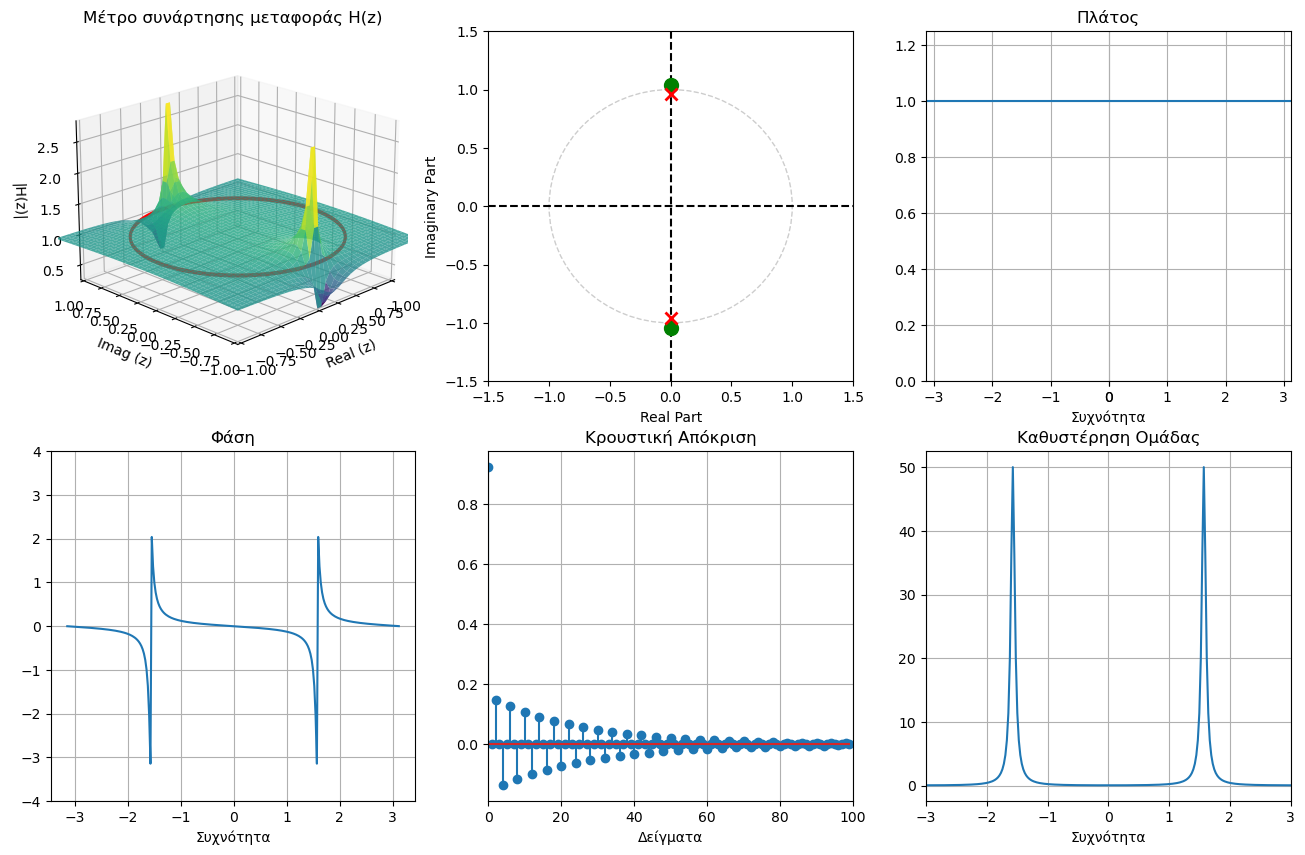

In [9]:
r = 49/51
w = np.pi/2

num2 = (sig.convolve([-r*np.exp(-1j*w), 1], [-r*np.exp(1j*w), 1]))
den2 = (sig.convolve([1, -r*np.exp(1j*w)], [1, -r*np.exp(-1j*w)]))

pezw2(num2, den2)

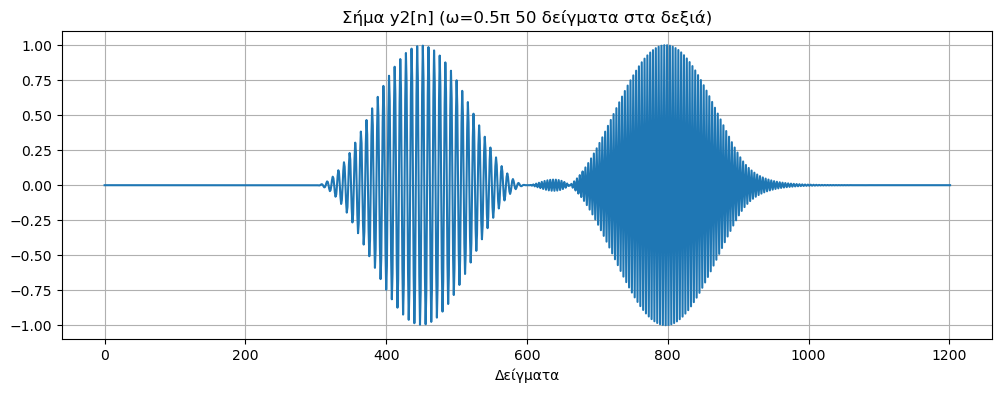

In [10]:
# Φιλτράρισμα και γράφημα εξόδου
y2 = sig.lfilter(num2, den2, x)

plt.figure(figsize=(12,4))
plt.plot(y2)
plt.grid(True)
plt.xlabel('Δείγματα')
plt.title('Σήμα y2[n] (ω=0.5π 50 δείγματα στα δεξιά)')
plt.show()

iv. Δημιουργήστε ένα **πραγματικό** all-pass σύστημα το οποίο να μετατοπίζει και τα δυο ημίτονα κατά $50$ δείγματα.
Όμοια με πριν, βρείτε τους συντελεστές του συστήματος, για αριθμητή και παρονομαστή. Καλέστε τη συνάρτηση ``pezw2`` με κατάλληλα ορίσματα. Περάστε το σήμα σας μέσα από το σύστημα (εντολή ``sig.lfilter``). Τυπώστε (εντολή ``plt.plot``) το αποτέλεσμα της εξόδου.

<u>**Απάντηση**</u>

Για να μετακινηθούν και τα $2$ ημίτονα κατά $50$ δείγματα μέσω ενός All-pass συστήματος, πρέπει να συνδέσουμε
τα συστήματα που φτιάξαμε στα ερωτήματα (ii), (iii) σε σειρά. Έτσι, για το τελικό σύστημα θα ισχύει:
$$H(z) = H_{1}(z)H_{2}(z) \Rightarrow H(z) = \frac{(-\frac{49}{51}e^{-j\frac{\pi}{4}} + z^{-1})(-\frac{49}{51}e^{j\frac{\pi}{4}} + z^{-1})(-\frac{49}{51}e^{-j\frac{\pi}{2}} + z^{-1})(-\frac{49}{51}e^{j\frac{\pi}{2}} + z^{-1})}{(1 -\frac{49}{51}e^{j\frac{\pi}{4}}z^{-1})(1 -\frac{49}{51}e^{-j\frac{\pi}{4}}z^{-1})(1 -\frac{49}{51}e^{j\frac{\pi}{2}}z^{-1})(1 -\frac{49}{51}e^{-j\frac{\pi}{2}}z^{-1})}$$




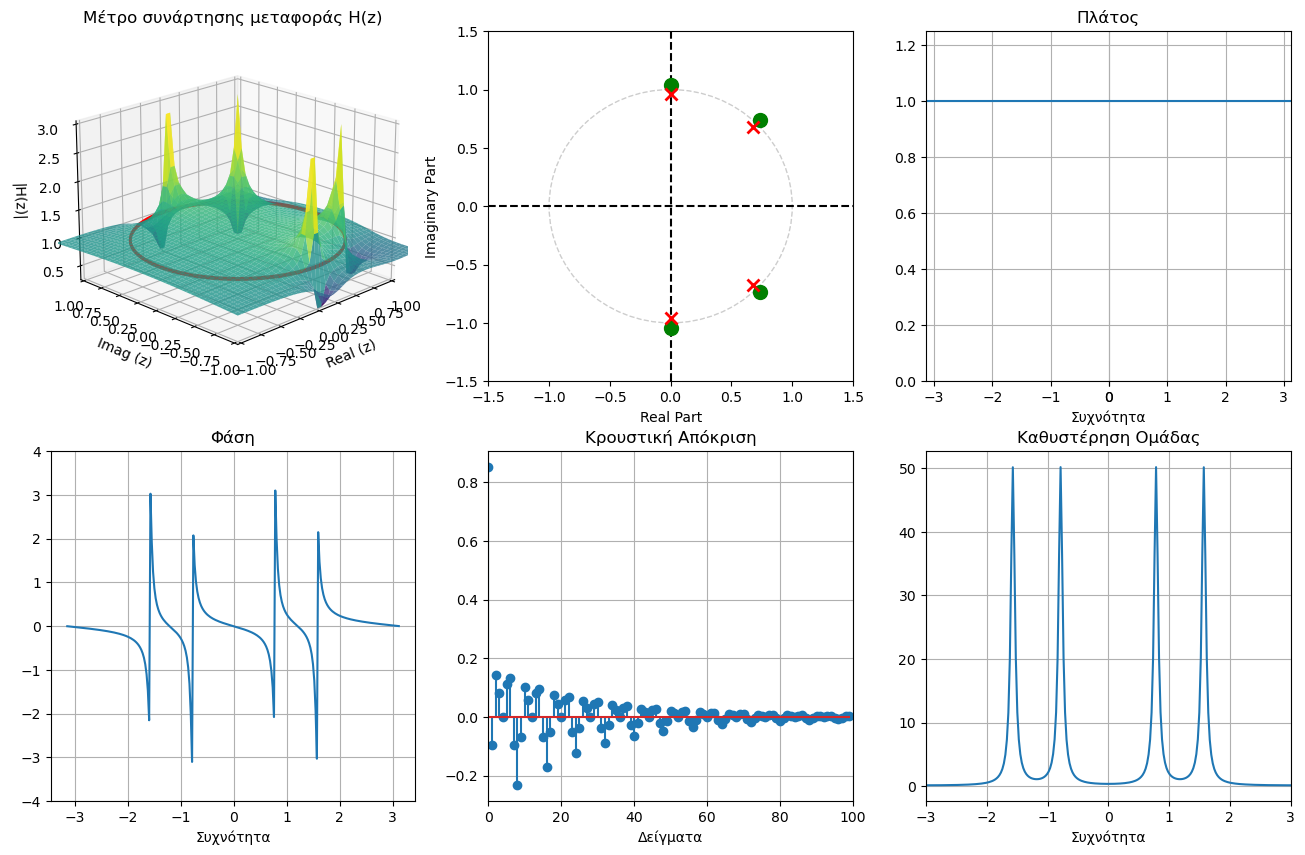

In [11]:
r = 49/51
w1 = np.pi/4
w2 = np.pi/2

B1 = sig.convolve([-r*np.exp(-1j*w1), 1], [-r*np.exp(1j*w1), 1])
B2 = sig.convolve([-r*np.exp(-1j*w2), 1], [-r*np.exp(1j*w2), 1])
num3 = sig.convolve(B1, B2)

A1 = sig.convolve([1, -r*np.exp(1j*w1)], [1, -r*np.exp(-1j*w1)])
A2 = sig.convolve([1, -r*np.exp(1j*w2)], [1, -r*np.exp(-1j*w2)])
den3 = sig.convolve(A1, A2)

pezw2(num3, den3)

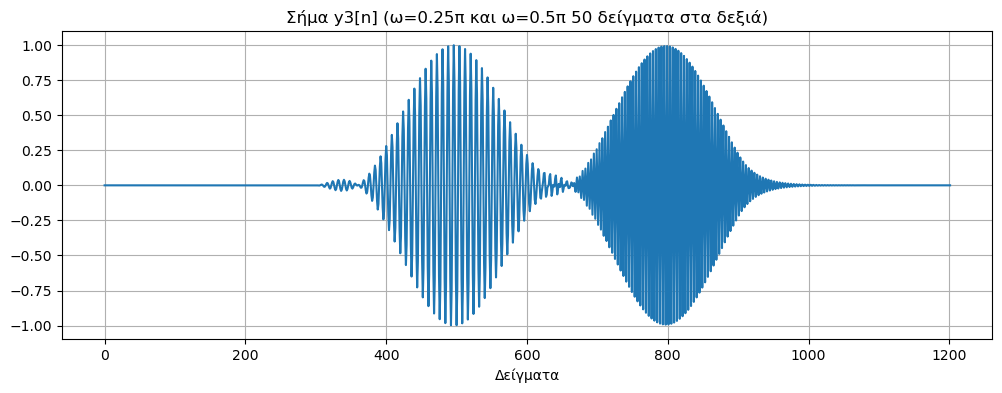

In [12]:
# Filter and print output
y3 = sig.lfilter(num3, den3, x)

plt.figure(figsize=(12,4))
plt.plot(y3)
plt.grid(True)
plt.xlabel('Δείγματα')
plt.title('Σήμα y3[n] (ω=0.25π και ω=0.5π 50 δείγματα στα δεξιά)')
plt.show()

v. Υπάρχει πιο απλός τρόπος να μετατοπίσετε και τις δυο συχνότητες, δηλ. όλο το σήμα, κατά $50$ δείγματα με ένα πιο απλό και πιο ακριβές σύστημα? Ποιό είναι αυτό? Γράψτε τη σχέση που χαρακτηρίζει το σύστημα στο χώρο του Ζ και καλέστε την ``pezw2`` για να επιβεβαιώσετε τη λύση σας.

<u>**Απάντηση**</u>


Ένα πιο απλό και ακριβές σύστημα για να μετακινηθούν και τα $2$ ημίτονα κατά $50$ δείγματα, θα ήταν το εξής:
$$y[n] = x[n-50] \overset{\Zeta}{\longleftrightarrow} Y(z) = z^{-50} X(z) \Rightarrow H(z) = z^{-50} $$


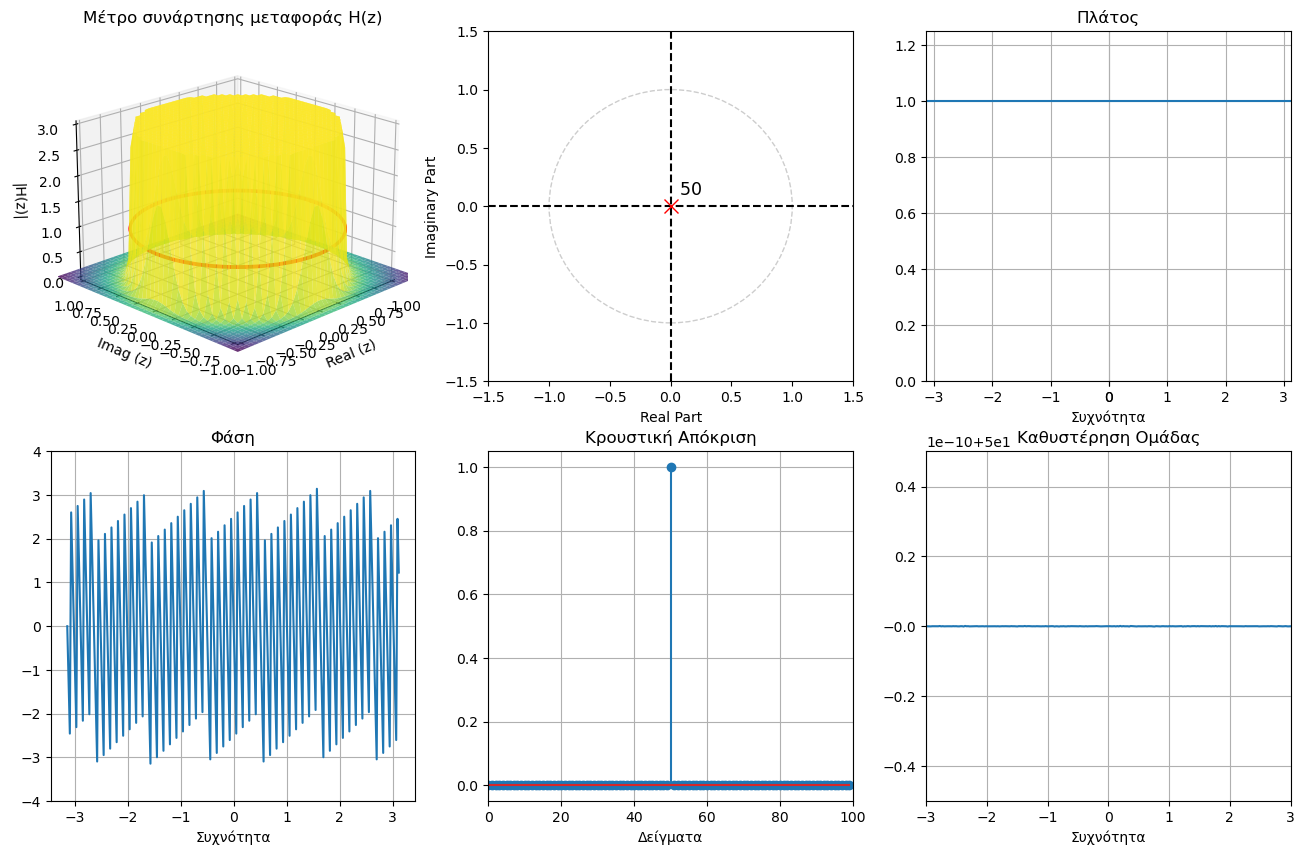

In [13]:
dn = 50
num4 = np.hstack([np.zeros((1,dn))[0], 1])
den4 = [1]

# Η καθυστέρηση ομάδας έχει κάποια θέματα - μη δώσετε σημασία
pezw2(num4, den4)

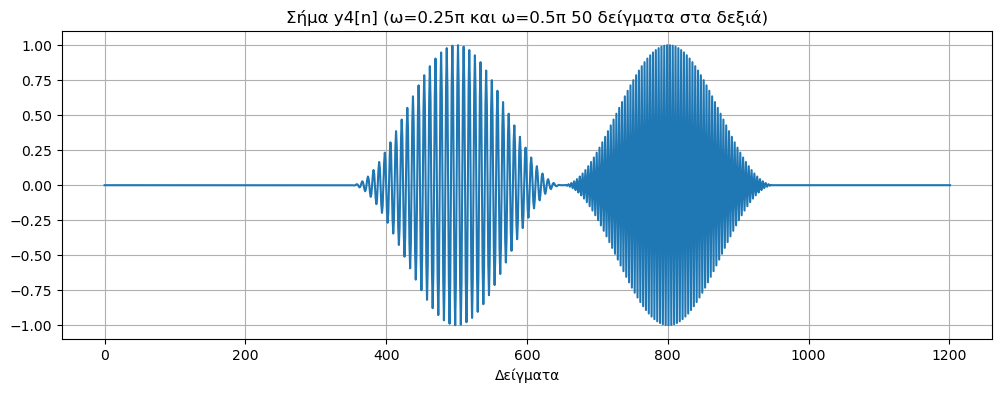

In [14]:
# Φιλτράρισμα και γράφημα εξόδου
y4 = sig.lfilter(num4, den4, x)

plt.figure(figsize=(12,4))
plt.plot(y4)
plt.grid(True)
plt.xlabel('Δείγματα')
plt.title('Σήμα y4[n] (ω=0.25π και ω=0.5π 50 δείγματα στα δεξιά)')
plt.show()

---
---